In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
import seaborn as sns
from upsetplot import UpSet, from_indicators

In [ ]:
data = pd.read_csv("C:\Users\avika\OneDrive\Desktop\MRP\HI-Small_Trans.csv")
data

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


In [40]:
data.head(10)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0
5,2022/09/01 00:03,1,8000F5AD0,1,8000F5AD0,6162.44,US Dollar,6162.44,US Dollar,Reinvestment,0
6,2022/09/01 00:08,1,8000EBAC0,1,8000EBAC0,14.26,US Dollar,14.26,US Dollar,Reinvestment,0
7,2022/09/01 00:16,1,8000EC1E0,1,8000EC1E0,11.86,US Dollar,11.86,US Dollar,Reinvestment,0
8,2022/09/01 00:26,12,8000EC280,2439,8017BF800,7.66,US Dollar,7.66,US Dollar,Credit Card,0
9,2022/09/01 00:21,1,8000EDEC0,211050,80AEF5310,383.71,US Dollar,383.71,US Dollar,Credit Card,0


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [42]:
object_cols = data.select_dtypes('object').columns.drop('Timestamp')
data[object_cols] = data[object_cols].astype('string')

In [43]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int64         
 2   Account             string        
 3   To Bank             int64         
 4   Account.1           string        
 5   Amount Received     float64       
 6   Receiving Currency  string        
 7   Amount Paid         float64       
 8   Payment Currency    string        
 9   Payment Format      string        
 10  Is Laundering       int64         
dtypes: datetime64[ns](1), float64(2), int64(3), string(5)
memory usage: 426.2 MB


In [45]:
data.duplicated().sum()

9

In [46]:
data.drop_duplicates()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022-09-10 23:57:00,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022-09-10 23:35:00,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022-09-10 23:52:00,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022-09-10 23:46:00,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


In [47]:
data.isna().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [48]:
data.describe()

,Timestamp,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5078345,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,2022-09-05 07:16:08.194274816,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
min,2022-09-01 00:00:00,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,2022-09-02 04:32:00,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,2022-09-05 12:16:00,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2022-09-08 03:13:00,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,2022-09-18 16:18:00,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00
std,NaN,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02


In [49]:
data['Payment Format'].value_counts()

Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: Int64

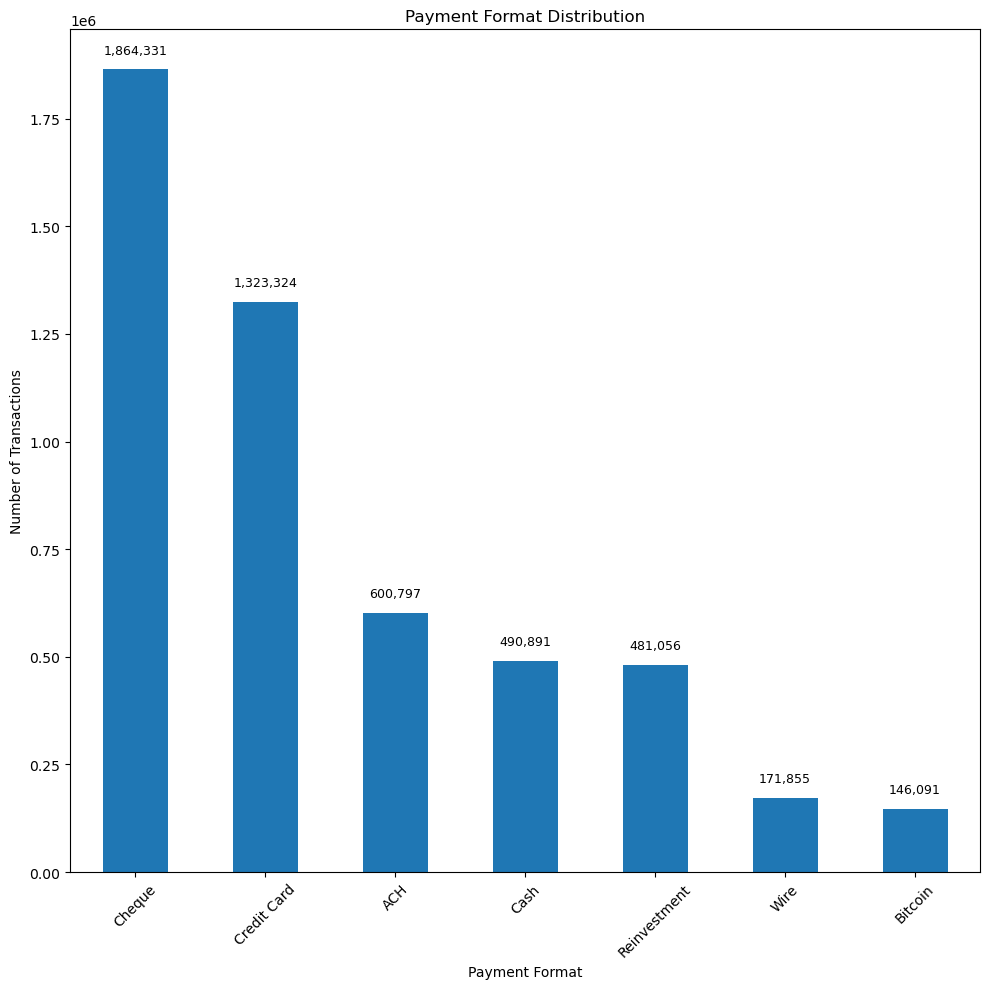

In [50]:
counts = data['Payment Format'].value_counts()
plt.figure(figsize=(10,10))
ax = counts.plot(kind='bar')
plt.ylabel('Number of Transactions')
plt.title('Payment Format Distribution')

for i, v in enumerate(counts):
    ax.text(i, v + 30000, f'{v:,}', ha='center', va='bottom', fontsize=9, rotation=0)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


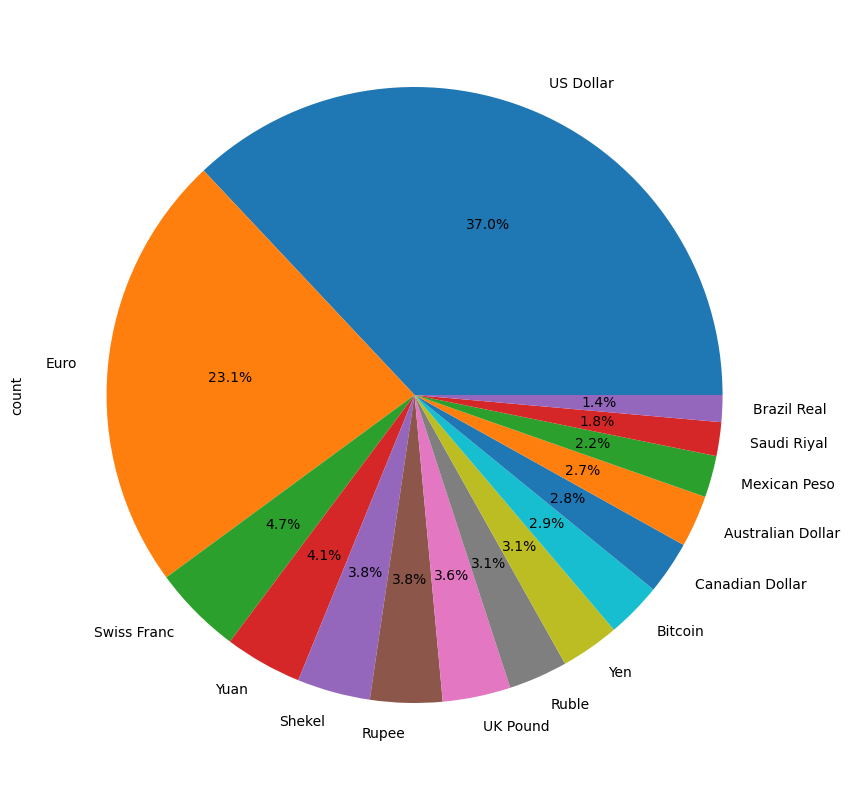

In [51]:
plt.figure(figsize=(10,10))
data['Receiving Currency'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

In [52]:
data['Is Laundering'].value_counts()

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

<Axes: xlabel='Is Laundering'>

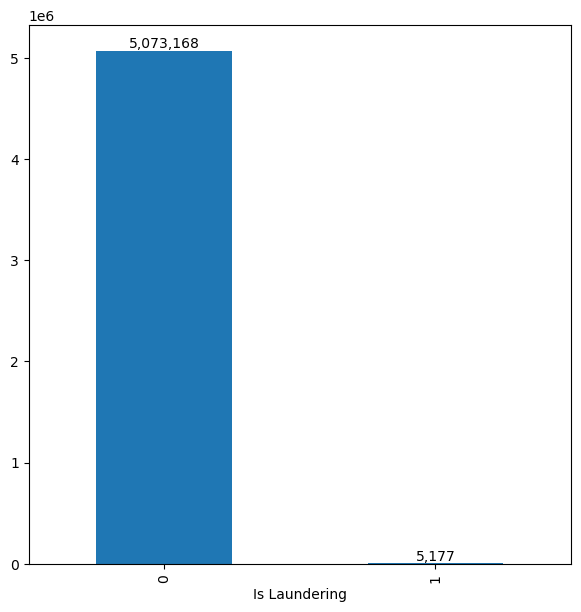

In [53]:
plt.figure(figsize=(7,7))
counts = data['Is Laundering'].value_counts()
ax = counts.plot(kind='bar')
for i,v in enumerate(data['Is Laundering'].value_counts()):
    ax.text(i, v, f'{v:,}',ha='center', va='bottom')
data['Is Laundering'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Laundering Rate by Payment Format')

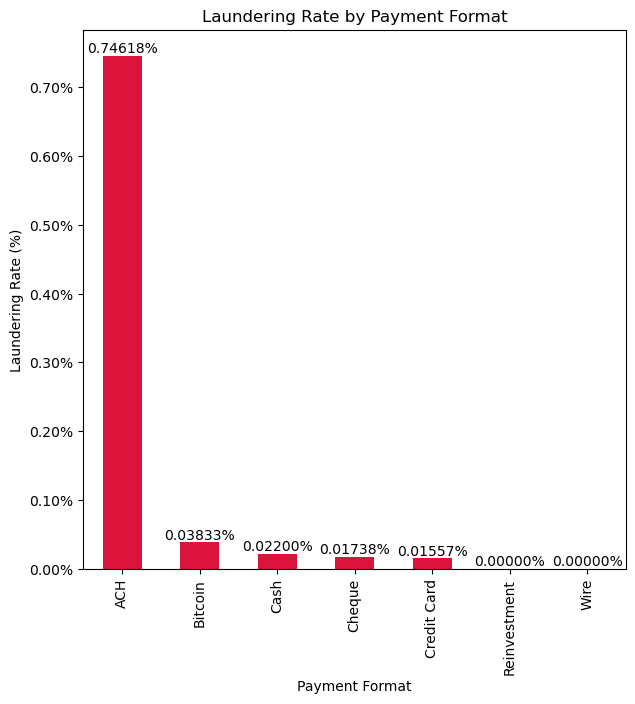

In [54]:
plt.figure(figsize=(7,7))
laundering_by_format = data.groupby('Payment Format')['Is Laundering'].mean().sort_values(ascending=False)
ax = laundering_by_format.plot(kind='bar')
for i,v in enumerate(laundering_by_format):
    ax.text(i,v,f'{v:.5%}',va = 'bottom',ha = 'center')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
laundering_by_format.plot(kind='bar', color='crimson')
plt.ylabel('Laundering Rate (%)')
plt.title('Laundering Rate by Payment Format')

In [55]:
numeric_data = data.select_dtypes('number')

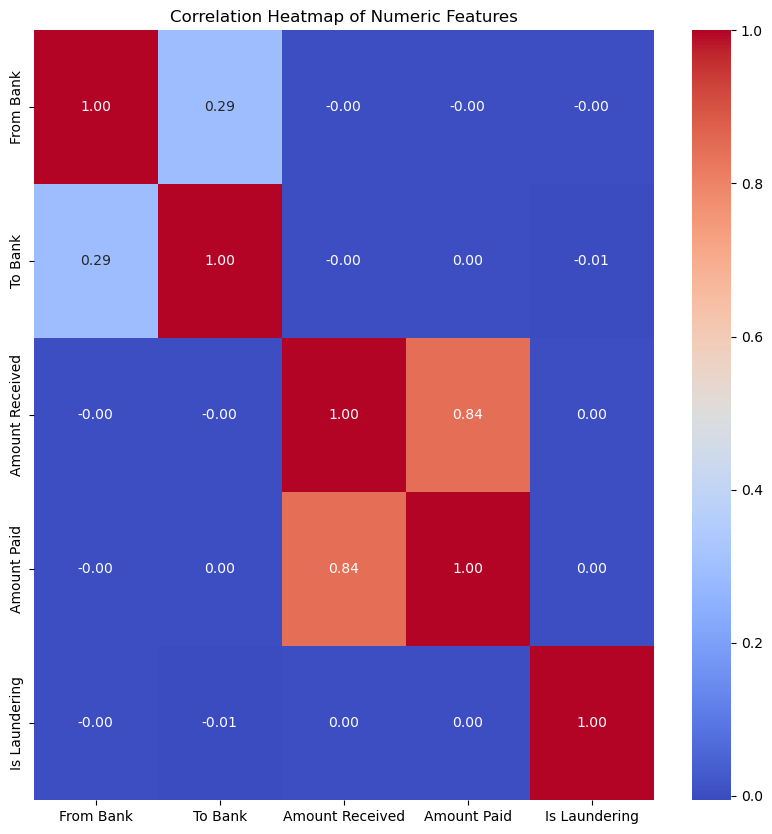

In [56]:
plt.figure(figsize=(10,10))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = data.select_dtypes(include=['string']).columns
for col in categorical_columns:
    data[col] = le.fit_transform(data[col])
data.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,942,10,900,3697.34,12,3697.34,12,5,0
1,2022-09-01 00:20:00,3208,990,1,949,0.01,12,0.01,12,3,0
2,2022-09-01 00:00:00,3209,991,3209,940,14675.57,12,14675.57,12,5,0
3,2022-09-01 00:02:00,12,997,12,945,2806.97,12,2806.97,12,5,0
4,2022-09-01 00:06:00,10,999,10,947,36682.97,12,36682.97,12,5,0


In [58]:
from sklearn.feature_selection import mutual_info_classif

X = data.drop(['Is Laundering','Timestamp'], axis=1)
y = data['Is Laundering']

mi_scores = mutual_info_classif(X, y, discrete_features='auto')

In [21]:
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print(mi_df)

              Feature  MI Score
8      Payment Format  0.204051
7    Payment Currency  0.138437
5  Receiving Currency  0.138146
3           Account.1  0.001476
1             Account  0.001408
2             To Bank  0.000821
0           From Bank  0.000698
6         Amount Paid  0.000501
4     Amount Received  0.000472


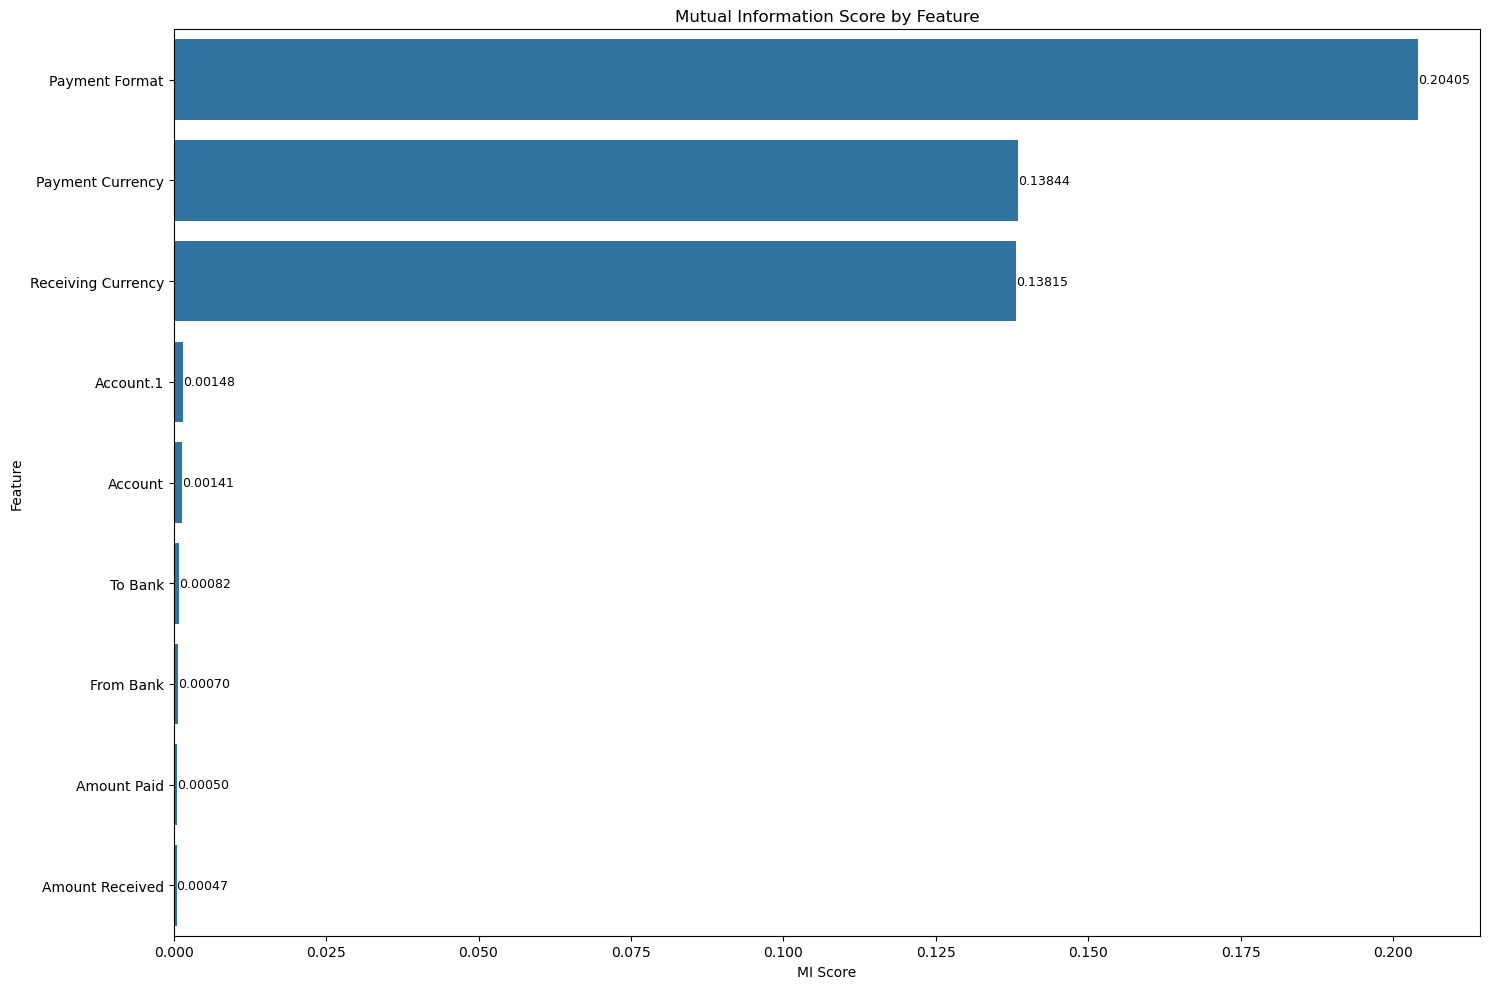

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

ax = sns.barplot(x='MI Score', y='Feature', data=mi_df)

for i, v in enumerate(mi_df['MI Score']):
    ax.text(v, i, f'{v:.5f}', va='center', ha='left', fontsize=9, rotation='horizontal')

plt.title('Mutual Information Score by Feature')
plt.tight_layout()
plt.show()


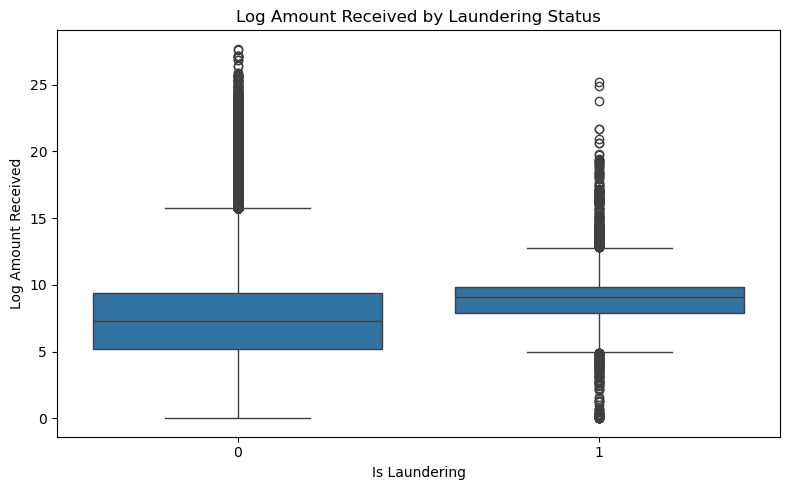

In [23]:
data['Log Amount Received'] = np.log1p(data['Amount Received'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='Is Laundering', y='Log Amount Received', data=data)
plt.title('Log Amount Received by Laundering Status')
plt.tight_layout()
plt.show()


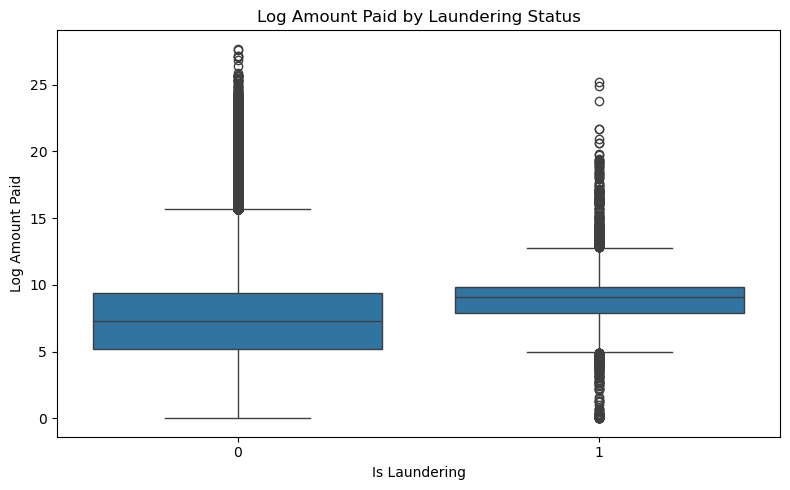

In [24]:
data['Log Amount Paid'] = np.log1p(data['Amount Paid'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='Is Laundering', y='Log Amount Paid', data=data)
plt.title('Log Amount Paid by Laundering Status')
plt.tight_layout()
plt.show()


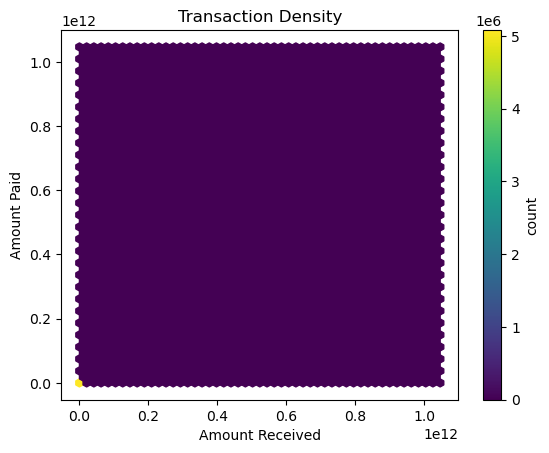

In [63]:
plt.hexbin(data["Amount Received"], data["Amount Paid"], gridsize=50)
plt.xlabel("Amount Received")
plt.ylabel("Amount Paid")
plt.title("Transaction Density")
plt.colorbar(label="count")
plt.show()


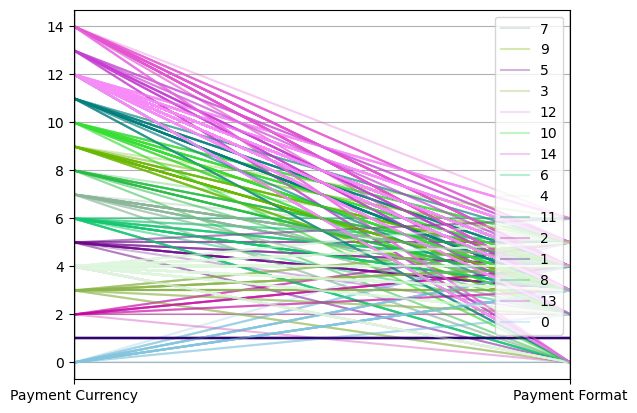

In [64]:
from pandas.plotting import parallel_coordinates

# pick a subset, map your codes back to strings (optional), and sample for clarity
sample = data.sample(1000)
parallel_coordinates(
    sample[["Receiving Currency","Payment Currency","Payment Format"]],
    class_column="Receiving Currency",
    alpha=0.3
)
plt.show()


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
# add edges weighted by sum of Amount Received
for (frm, to), amt in data.groupby(["From Bank", "To Bank"])["Amount Received"].sum().items():
    G.add_edge(frm, to, weight=amt)

pos = nx.spring_layout(G, k=0.3)
weights = [G[u][v]["weight"]/data["Amount Received"].sum()*10 for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_size=300, width=weights)
plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# build aggregated flows
flows = (
    data
      .groupby(["Receiving Currency", "Payment Currency", "Payment Format"])["Amount Received"]
      .sum()
      .reset_index()
)

# map each category to an integer node
labels = list(pd.unique(flows[["Receiving Currency", "Payment Currency", "Payment Format"]].values.ravel()))
label_idx = {lab:i for i,lab in enumerate(labels)}

fig = go.Figure(go.Sankey(
    node=dict(label=labels),
    link=dict(
        source=flows["Receiving Currency"].map(label_idx),
        target=flows["Payment Currency"].map(label_idx),
        value=flows["Amount Received"]
    )
))
fig.update_layout(title="Currency→Currency Flows", font_size=10)
fig.show()
